In [1]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
# 1. Load dataset

df = pd.read_csv('/content/1.data_20162017.csv')

In [4]:
df.head()

,Time,HVAC Actual [kW],Chiller Power [kW],Humidifier power [kW],HV light Power [kW],Power[kW],PV panels power [kW],Battery system power
0,01/01/2016 00:00,0.0,0.0,0.0,0.001,0.02,0.0,0.0
1,01/01/2016 00:01,0.0,0.0,0.0,0.001,0.02,0.0,0.0
2,01/01/2016 00:02,0.0,0.0,0.0,0.001,0.02,0.0,0.0
3,01/01/2016 00:03,0.0,0.0,0.0,0.001,0.02,0.0,0.0
4,01/01/2016 00:04,0.0,0.0,0.0,0.001,0.02,0.0,0.0


In [5]:
df.shape

(1048575, 8)

In [6]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (1048575, 8)


In [7]:
# Convert Time column to datetime

df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

In [8]:
df = df.dropna(subset=['Time'])   # Remove rows where Time is invalid

In [9]:
# Create time-based features

df['Hour'] = df['Time'].dt.hour
df['Day'] = df['Time'].dt.day
df['Month'] = df['Time'].dt.month
df['DayOfWeek'] = df['Time'].dt.dayofweek

In [10]:
# Drop the original Time column

df = df.drop(['Time'], axis=1)

In [11]:
# Handle all other NaN values
# Method: Fill with column mean (better than drop)

df = df.fillna(df.mean(numeric_only=True))

In [12]:
print(df.columns)


Index(['HVAC Actual [kW]', 'Chiller Power [kW]', 'Humidifier power [kW]',
       'HV light Power [kW]', 'Power[kW]', 'PV panels power [kW]',
       'Battery system power', 'Hour', 'Day', 'Month', 'DayOfWeek'],
      dtype='object')


In [13]:
# Select Features (X) and Target (y)

y = df['Power[kW]']
X = df.drop(['Power[kW]'], axis=1)

In [14]:
X.head()

,HVAC Actual [kW],Chiller Power [kW],Humidifier power [kW],HV light Power [kW],PV panels power [kW],Battery system power,Hour,Day,Month,DayOfWeek
0,0.0,0.0,0.0,0.001,0.0,0.0,0,1,1,4
1,0.0,0.0,0.0,0.001,0.0,0.0,0,1,1,4
2,0.0,0.0,0.0,0.001,0.0,0.0,0,1,1,4
3,0.0,0.0,0.0,0.001,0.0,0.0,0,1,1,4
4,0.0,0.0,0.0,0.001,0.0,0.0,0,1,1,4


In [15]:
X.dtypes

,0
HVAC Actual [kW],float64
Chiller Power [kW],float64
Humidifier power [kW],float64
HV light Power [kW],float64
PV panels power [kW],float64
Battery system power,float64
Hour,int32
Day,int32
Month,int32
DayOfWeek,int32


In [16]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# 1. Scale X and y properly
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [18]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 4. Train on scaled y
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/200
4146/4146 - 11s - 3ms/step - loss: 0.0510 - mae: 0.1166 - val_loss: 0.0502 - val_mae: 0.1252
Epoch 2/200
4146/4146 - 11s - 3ms/step - loss: 0.0501 - mae: 0.1149 - val_loss: 0.0512 - val_mae: 0.1090
Epoch 3/200
4146/4146 - 11s - 3ms/step - loss: 0.0498 - mae: 0.1142 - val_loss: 0.0483 - val_mae: 0.1100
Epoch 4/200
4146/4146 - 11s - 3ms/step - loss: 0.0494 - mae: 0.1137 - val_loss: 0.0559 - val_mae: 0.1259
Epoch 5/200
4146/4146 - 12s - 3ms/step - loss: 0.0489 - mae: 0.1129 - val_loss: 0.0626 - val_mae: 0.1291
Epoch 6/200
4146/4146 - 10s - 2ms/step - loss: 0.0485 - mae: 0.1123 - val_loss: 0.0560 - val_mae: 0.1218
Epoch 7/200
4146/4146 - 11s - 3ms/step - loss: 0.0485 - mae: 0.1118 - val_loss: 0.0623 - val_mae: 0.1338
Epoch 8/200
4146/4146 - 11s - 3ms/step - loss: 0.0481 - mae: 0.1113 - val_loss: 0.0644 - val_mae: 0.1385
Epoch 9/200
4146/4146 - 11s - 3ms/step - loss: 0.0479 - mae: 0.1109 - val_loss: 0.0596 - val_mae: 0.1303
Epoch 10/200
4146/4146 - 11s - 3ms/step - loss: 0.0477 

In [26]:
# 5. Predict and inverse transform
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

2591/2591 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}, RMSE: {rmse}, R²: {r2}")


MAE: 0.6943718720379526, RMSE: 1.3736873797615379, R²: 0.9512215435454174


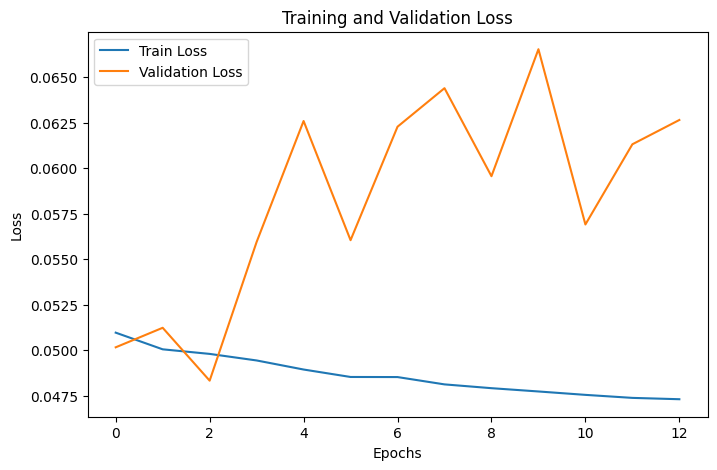

In [28]:
# 1. Plot Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

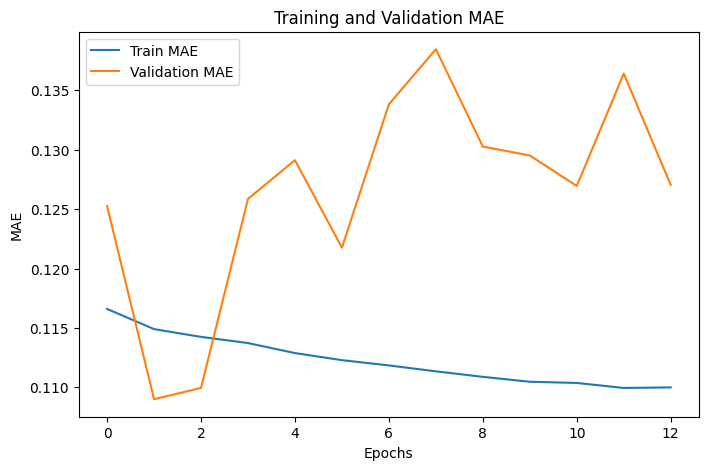

In [29]:
# 2. Plot Training vs Validation MAE
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

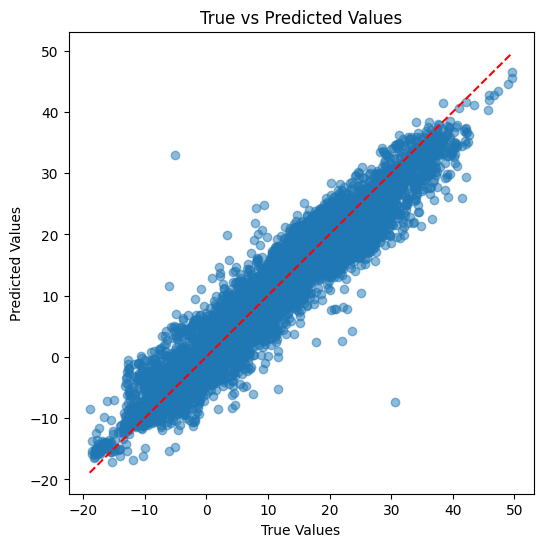

In [30]:
# 3. True vs Predicted Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('True vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()